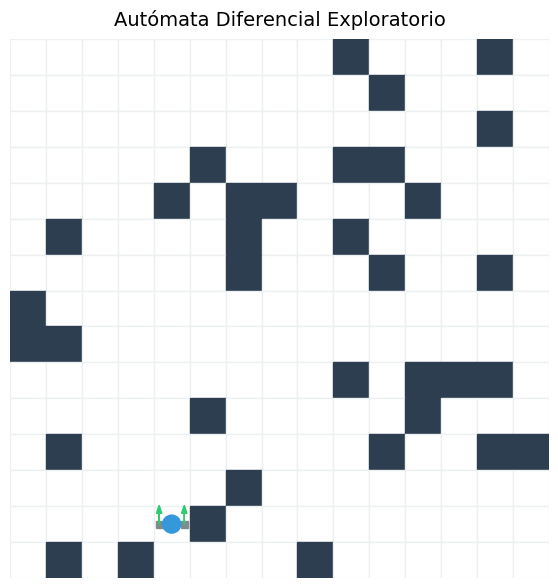

Simulación completada.


In [5]:
import random
import time
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from IPython.display import display # Ya no necesitamos clear_output

# ==========================================
# 1. PARÁMETROS DEL AUTÓMATA
# ==========================================
n, m = 15, 15
K = 35         # Número de obstáculos
ciclos = 100
probabilidad_giro_aleatorio = 0.05  # Reducido al 5% de probabilidad

# ==========================================
# 2. INICIALIZACIÓN (Lógica pura de Python)
# ==========================================
reticulo = [[0 for _ in range(m)] for _ in range(n)]

# Colocar obstáculos
obstaculos = 0
while obstaculos < K:
    r, c = random.randint(0, n - 1), random.randint(0, m - 1)
    if reticulo[r][c] == 0:
        reticulo[r][c] = 1
        obstaculos += 1

# Colocar robot
robot_r, robot_c = random.randint(0, n - 1), random.randint(0, m - 1)
while reticulo[robot_r][robot_c] != 0:
    robot_r, robot_c = random.randint(0, n - 1), random.randint(0, m - 1)
reticulo[robot_r][robot_c] = 2

# 0: Norte, 1: Este, 2: Sur, 3: Oeste
movimientos = [(-1, 0), (0, 1), (1, 0), (0, -1)]
dir_actual = random.randint(0, 3)

# ==========================================
# 3. CONFIGURACIÓN DEL RENDERIZADO (Display Handle)
# ==========================================
# Creamos la figura UNA sola vez
fig, ax = plt.subplots(figsize=(7, 7))
plt.close(fig) # Evita que Colab imprima una versión estática de la figura al inicio

# ¡LA CLAVE AQUÍ!: Creamos un identificador único para actualizar el mismo canvas en el navegador
dh = display(fig, display_id=True)

def dibujar_entorno(matriz, r_rob, c_rob, direccion, estado_motor="avanzando"):
    ax.clear() # Limpiar los ejes en memoria es casi instantáneo

    # Dibujar cuadrícula y obstáculos
    for i in range(n):
        for j in range(m):
            if matriz[i][j] == 1:
                ax.add_patch(patches.Rectangle((j-0.5, i-0.5), 1, 1, color='#2c3e50'))
            elif matriz[i][j] == 0:
                ax.add_patch(patches.Rectangle((j-0.5, i-0.5), 1, 1, color='white', ec='#ecf0f1'))

    offsets_ruedas = {
        0: ((-0.35, 0), (0.35, 0)),  1: ((0, -0.35), (0, 0.35)),
        2: ((0.35, 0), (-0.35, 0)),  3: ((0, 0.35), (0, -0.35))
    }
    vectores_motor = {0: (0, -0.3), 1: (0.3, 0), 2: (0, 0.3), 3: (-0.3, 0)}

    # Cuerpo del robot
    ax.add_patch(patches.Circle((c_rob, r_rob), 0.25, color='#3498db', zorder=5))

    # Lógica de motores
    motor_izq, motor_der = vectores_motor[direccion], vectores_motor[direccion]
    color_izq, color_der = '#2ecc71', '#2ecc71' # Verde

    if estado_motor == "girando_der":
        color_der = '#e74c3c' # Rojo (Reversa)
        motor_der = (-motor_der[0], -motor_der[1])
    elif estado_motor == "girando_izq":
        color_izq = '#e74c3c'
        motor_izq = (-motor_izq[0], -motor_izq[1])
    elif estado_motor == "reversa":
        color_izq, color_der = '#e74c3c', '#e74c3c'
        motor_izq = (-motor_izq[0], -motor_izq[1])
        motor_der = (-motor_der[0], -motor_der[1])

    off_izq, off_der = offsets_ruedas[direccion]

    # Rueda Izquierda
    ax.add_patch(patches.Rectangle((c_rob+off_izq[0]-0.1, r_rob+off_izq[1]-0.1), 0.2, 0.2, color='#7f8c8d', zorder=4))
    ax.arrow(c_rob+off_izq[0], r_rob+off_izq[1], motor_izq[0], motor_izq[1], head_width=0.15, color=color_izq, zorder=6)

    # Rueda Derecha
    ax.add_patch(patches.Rectangle((c_rob+off_der[0]-0.1, r_rob+off_der[1]-0.1), 0.2, 0.2, color='#7f8c8d', zorder=4))
    ax.arrow(c_rob+off_der[0], r_rob+off_der[1], motor_der[0], motor_der[1], head_width=0.15, color=color_der, zorder=6)

    ax.set_xlim(-0.5, m-0.5)
    ax.set_ylim(n-0.5, -0.5)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(f"Autómata Diferencial Exploratorio", fontsize=14, pad=10)

    # En lugar de destruir/crear la salida, actualizamos la imagen in-place usando el handle
    dh.update(fig)

# ==========================================
# 4. DINÁMICA DE SIMULACIÓN
# ==========================================
for ciclo in range(ciclos):
    dibujar_entorno(reticulo, robot_r, robot_c, dir_actual, "avanzando")
    time.sleep(0.05) # Puedes bajarlo a 0.01 si quieres que vaya rapidísimo

    dr, dc = movimientos[dir_actual]
    frente_r, frente_c = robot_r + dr, robot_c + dc
    frente_libre = (0 <= frente_r < n and 0 <= frente_c < m and reticulo[frente_r][frente_c] != 1)

    # 5% de probabilidad de tomar una decisión puramente estocástica
    quiere_girar_aleatorio = random.random() < probabilidad_giro_aleatorio

    if frente_libre and not quiere_girar_aleatorio:
        # Avanza normalmente
        reticulo[robot_r][robot_c] = 0
        robot_r, robot_c = frente_r, frente_c
        reticulo[robot_r][robot_c] = 2
    else:
        # Evalúa opciones si topa pared o decide explorar
        dir_izq = (dir_actual - 1) % 4
        dir_der = (dir_actual + 1) % 4

        r_izq, c_izq = robot_r + movimientos[dir_izq][0], robot_c + movimientos[dir_izq][1]
        r_der, c_der = robot_r + movimientos[dir_der][0], robot_c + movimientos[dir_der][1]

        izq_libre = (0 <= r_izq < n and 0 <= c_izq < m and reticulo[r_izq][c_izq] != 1)
        der_libre = (0 <= r_der < n and 0 <= c_der < m and reticulo[r_der][c_der] != 1)

        opciones_giro = []
        if izq_libre: opciones_giro.append((dir_izq, "girando_izq"))
        if der_libre: opciones_giro.append((dir_der, "girando_der"))

        if opciones_giro:
            # Gira usando el comportamiento diferencial de las ruedas
            dir_actual, estado_giro = random.choice(opciones_giro)
            dibujar_entorno(reticulo, robot_r, robot_c, dir_actual, estado_giro)
            time.sleep(0.15) # Pausa un poco más larga para que el "Tank Turn" sea apreciable

        elif not frente_libre:
            # Callejón sin salida: Reversa de ambas ruedas para giro de 180 grados
            dir_actual = (dir_actual + 2) % 4
            dibujar_entorno(reticulo, robot_r, robot_c, dir_actual, "reversa")
            time.sleep(0.15)

        else:
            # Quería girar pero está rodeado lateralmente; sigue derecho
            reticulo[robot_r][robot_c] = 0
            robot_r, robot_c = frente_r, frente_c
            reticulo[robot_r][robot_c] = 2

print("Simulación completada.")